# Data Exploration
WMH 2017 Challenge Dataset

Goals of this notebook:
1. Understand the folder structure and count cases per site
2. Check image shapes, spacings, and orientations across sites
3. Check WMH mask values and lesion statistics
4. Visualize T1, FLAIR, and WMH mask side by side for a few patients
5. Flag any anomalies

In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import random

# NOTE: Change this to match your data root
DATA_ROOT = Path('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training')
assert(DATA_ROOT.exists())

## 1. Count cases and build a case list

In [2]:
# Helper Functions for Checking Patients in different test sites and confirming file existence

def discover_cases(root):
    cases = []
    for site_dir in sorted(root.iterdir()):
        if not site_dir.is_dir():
            continue
        subdirs = [d for d in site_dir.iterdir() if d.is_dir()]
        if any(d.name.isdigit() for d in subdirs):
            scanner = site_dir.name
            patient_dirs = sorted([d for d in subdirs if d.is_dir()], key=lambda x: x.name)
            for pdir in patient_dirs:
                cases.append(build_case(scanner, pdir))
        else:
            for sub in sorted(subdirs):
                scanner = f'{site_dir.name}/{sub.name}'
                patient_dirs = sorted([d for d in sub.iterdir() if d.is_dir()],
                                      key=lambda x: x.name)
                for pdir in patient_dirs:
                    cases.append(build_case(scanner, pdir))
    return cases

def build_case(site, pdir):
    case = {
        'site': site,
        'patient_id': pdir.name,
        'flair': pdir / 'pre' / 'FLAIR.nii',
        't1':    pdir / 'pre' / 'T1.nii',
        'wmh':   pdir / 'wmh.nii',
    }
    case['missing'] = [k for k, v in case.items()
                       if isinstance(v, Path) and not v.exists()]
    return case

def print_case_summary(cases, label=''):
    if label:
        print(f'=== {label} ===')
    site_to_pids = defaultdict(list)
    for c in cases:
        site_to_pids[c['site']].append(c['patient_id'])
    usable = [c for c in cases if not c['missing']]
    for site, pids in sorted(site_to_pids.items()):
        print(f"{site}: {len(pids)} patients -> {sorted(pids)}")
    print(f'Total usable cases: {len(usable)}')
    missing_cases = [c for c in cases if c['missing']]
    if missing_cases:
        print(f'WARNING: {len(missing_cases)} cases have missing files:')
        for c in missing_cases:
            print(f"  {c['site']}/{c['patient_id']}: missing {c['missing']}")
    print()

In [3]:
# Note: Each patient has a pre/ and orig/ subdir with the FLAIR and T1
# pre/ = preprocessed (bias corrected, registered) — this is what I check in this notebook

cases = discover_cases(DATA_ROOT)
print_case_summary(cases, "TRAINING SET")

=== TRAINING SET ===
Amsterdam/GE3T: 20 patients -> ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '112', '113', '114', '115', '116', '126', '132', '137', '144']
Singapore: 20 patients -> ['50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69']
Utrecht: 20 patients -> ['0', '11', '17', '19', '2', '21', '23', '25', '27', '29', '31', '33', '35', '37', '39', '4', '41', '49', '6', '8']
Total usable cases: 60



In [4]:
print("Example Case: (Contains site, patient_ID and paths to 3 relevant files)")
cases[0]

Example Case: (Contains site, patient_ID and paths to 3 relevant files)


{'site': 'Amsterdam/GE3T',
 'patient_id': '100',
 'flair': PosixPath('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training/Amsterdam/GE3T/100/pre/FLAIR.nii'),
 't1': PosixPath('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training/Amsterdam/GE3T/100/pre/T1.nii'),
 'wmh': PosixPath('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training/Amsterdam/GE3T/100/wmh.nii'),
 'missing': []}

## 2. Check image shapes, spacings, and orientations across all cases

In [5]:
# Information we want:
# - Spacing --> "distance between pixels along each dimension of the image in the physical world coordinate system."
# - Size --> "the number of pixels the Image is in each dimension"

def get_image_info(path):
    img = sitk.ReadImage(str(path))
    return {
        'size': img.GetSize(),
        'spacing': tuple(round(s, 3) for s in img.GetSpacing()),
        'origin': tuple(round(o, 1) for o in img.GetOrigin()),
        'direction': img.GetDirection(),
    }

print(f"{'Site':<12} {'PID':<6} {'FLAIR shape':<20} {'FLAIR spacing':<25} {'T1 shape':<20} {'T1 spacing'}")
print('-' * 100)

shapes = defaultdict(set)
spacings = defaultdict(set)

for case in cases:
    flair_info = get_image_info(case['flair'])
    t1_info    = get_image_info(case['t1'])
    site = case['site']
    
    shapes[site].add(flair_info['size'])
    spacings[site].add(flair_info['spacing'])
    
    print(f"{site:<12} {case['patient_id']:<6} {str(flair_info['size']):<20} {str(flair_info['spacing']):<25} {str(t1_info['size']):<20} {str(t1_info['spacing'])}")

Site         PID    FLAIR shape          FLAIR spacing             T1 shape             T1 spacing
----------------------------------------------------------------------------------------------------
Amsterdam/GE3T 100    (132, 256, 83)       (1.2, 0.977, 3.0)         (132, 256, 83)       (1.2, 0.977, 3.0)
Amsterdam/GE3T 101    (132, 256, 83)       (1.2, 0.977, 3.0)         (132, 256, 83)       (1.2, 0.977, 3.0)
Amsterdam/GE3T 102    (132, 256, 83)       (1.2, 0.977, 3.0)         (132, 256, 83)       (1.2, 0.977, 3.0)
Amsterdam/GE3T 103    (132, 256, 83)       (1.2, 0.977, 3.0)         (132, 256, 83)       (1.2, 0.977, 3.0)
Amsterdam/GE3T 104    (132, 256, 83)       (1.2, 0.977, 3.0)         (132, 256, 83)       (1.2, 0.977, 3.0)
Amsterdam/GE3T 105    (132, 256, 83)       (1.2, 0.977, 3.0)         (132, 256, 83)       (1.2, 0.977, 3.0)
Amsterdam/GE3T 106    (132, 256, 83)       (1.2, 0.977, 3.0)         (132, 256, 83)       (1.2, 0.977, 3.0)
Amsterdam/GE3T 107    (132, 256, 83)       (

In [6]:
# This tells us that we need to standardize since these are not the same across (or even within) sites:

print('\n--- Unique FLAIR shapes per site ---')
for site, sh in shapes.items():
    print(f'  {site}: {sh}')

print('\n--- Unique FLAIR spacings per site ---')
for site, sp in spacings.items():
    print(f'  {site}: {sp}')


--- Unique FLAIR shapes per site ---
  Amsterdam/GE3T: {(132, 256, 83)}
  Singapore: {(256, 232, 48), (232, 256, 48)}
  Utrecht: {(240, 240, 48)}

--- Unique FLAIR spacings per site ---
  Amsterdam/GE3T: {(1.2, 0.977, 3.0)}
  Singapore: {(1.0, 1.0, 3.0)}
  Utrecht: {(0.958, 0.958, 3.0)}


## 3. Check WMH mask values and lesion load statistics

In [7]:
wmh_stats = []

for case in cases:
    wmh_img = sitk.ReadImage(str(case['wmh']))
    wmh_arr = sitk.GetArrayFromImage(wmh_img)
    
    unique_vals = np.unique(wmh_arr)
    lesion_voxels = np.sum(wmh_arr > 0)
    total_voxels = wmh_arr.size
    spacing = wmh_img.GetSpacing()  # (x, y, z)
    voxel_vol_mm3 = spacing[0] * spacing[1] * spacing[2]
    lesion_vol_ml = (lesion_voxels * voxel_vol_mm3) / 1000
    
    wmh_stats.append({
        'site': case['site'],
        'pid': case['patient_id'],
        'unique_vals': unique_vals,
        'lesion_voxels': lesion_voxels,
        'lesion_vol_ml': round(lesion_vol_ml, 3),
        'shape': wmh_arr.shape,
    })

print(f"{'Site':<12} {'PID':<6} {'Unique mask vals':<25} {'Lesion voxels':<18} {'Lesion vol (ml)'}")
print('-' * 80)
for s in wmh_stats:
    print(f"{s['site']:<12} {s['pid']:<6} {str(s['unique_vals']):<25} {s['lesion_voxels']:<18} {s['lesion_vol_ml']}")


Site         PID    Unique mask vals          Lesion voxels      Lesion vol (ml)
--------------------------------------------------------------------------------
Amsterdam/GE3T 100    [0. 1.]                   1784               6.272
Amsterdam/GE3T 101    [0. 1.]                   885                3.111
Amsterdam/GE3T 102    [0. 1.]                   1239               4.356
Amsterdam/GE3T 103    [0. 1.]                   6461               22.715
Amsterdam/GE3T 104    [0. 1. 2.]                8820               31.009
Amsterdam/GE3T 105    [0. 1. 2.]                3307               11.627
Amsterdam/GE3T 106    [0. 1.]                   861                3.027
Amsterdam/GE3T 107    [0. 1. 2.]                2269               7.977
Amsterdam/GE3T 108    [0. 1. 2.]                448                1.575
Amsterdam/GE3T 109    [0. 1.]                   548                1.927
Amsterdam/GE3T 110    [0. 1.]                   917                3.224
Amsterdam/GE3T 112    [0. 1.]   

In [8]:
# Summary stats
vols = [s['lesion_vol_ml'] for s in wmh_stats]
print(f'\nLesion volume (ml) — min: {min(vols):.3f}, max: {max(vols):.3f}, mean: {np.mean(vols):.3f}, std: {np.std(vols):.3f}')


Lesion volume (ml) — min: 0.915, max: 74.991, mean: 20.203, std: 19.278


In [9]:
# Check for any non-binary masks (Which we have to deal with)
# Value of 2 in this dataset means other pathologies -- Have to choose whether we make it the background or the foregound
non_binary = [s for s in wmh_stats if not set(s['unique_vals']).issubset({0, 1})]
if non_binary:
    print(f'\nWARNING: These cases have non-binary mask values:')
    for s in non_binary:
        print(f"  {s['site']}/{s['pid']}: {s['unique_vals']}")
else:
    print('\nAll masks are binary (0/1) — good!')


  Amsterdam/GE3T/104: [0. 1. 2.]
  Amsterdam/GE3T/105: [0. 1. 2.]
  Amsterdam/GE3T/107: [0. 1. 2.]
  Amsterdam/GE3T/108: [0. 1. 2.]
  Amsterdam/GE3T/113: [0. 1. 2.]
  Singapore/51: [0. 1. 2.]
  Singapore/54: [0. 1. 2.]
  Singapore/59: [0. 1. 2.]
  Singapore/60: [0. 1. 2.]
  Singapore/61: [0. 1. 2.]
  Singapore/62: [0. 1. 2.]
  Singapore/63: [0. 1. 2.]
  Singapore/64: [0. 1. 2.]
  Singapore/65: [0. 1. 2.]
  Singapore/67: [0. 1. 2.]
  Singapore/68: [0. 1. 2.]
  Utrecht/0: [0. 1. 2.]
  Utrecht/11: [0. 1. 2.]
  Utrecht/17: [0. 1. 2.]
  Utrecht/19: [0. 1. 2.]
  Utrecht/25: [0. 1. 2.]
  Utrecht/27: [0. 1. 2.]
  Utrecht/29: [0. 1. 2.]
  Utrecht/4: [0. 1. 2.]
  Utrecht/41: [0. 1. 2.]


## 4. Visualize T1, FLAIR, and WMH mask for one patient per site

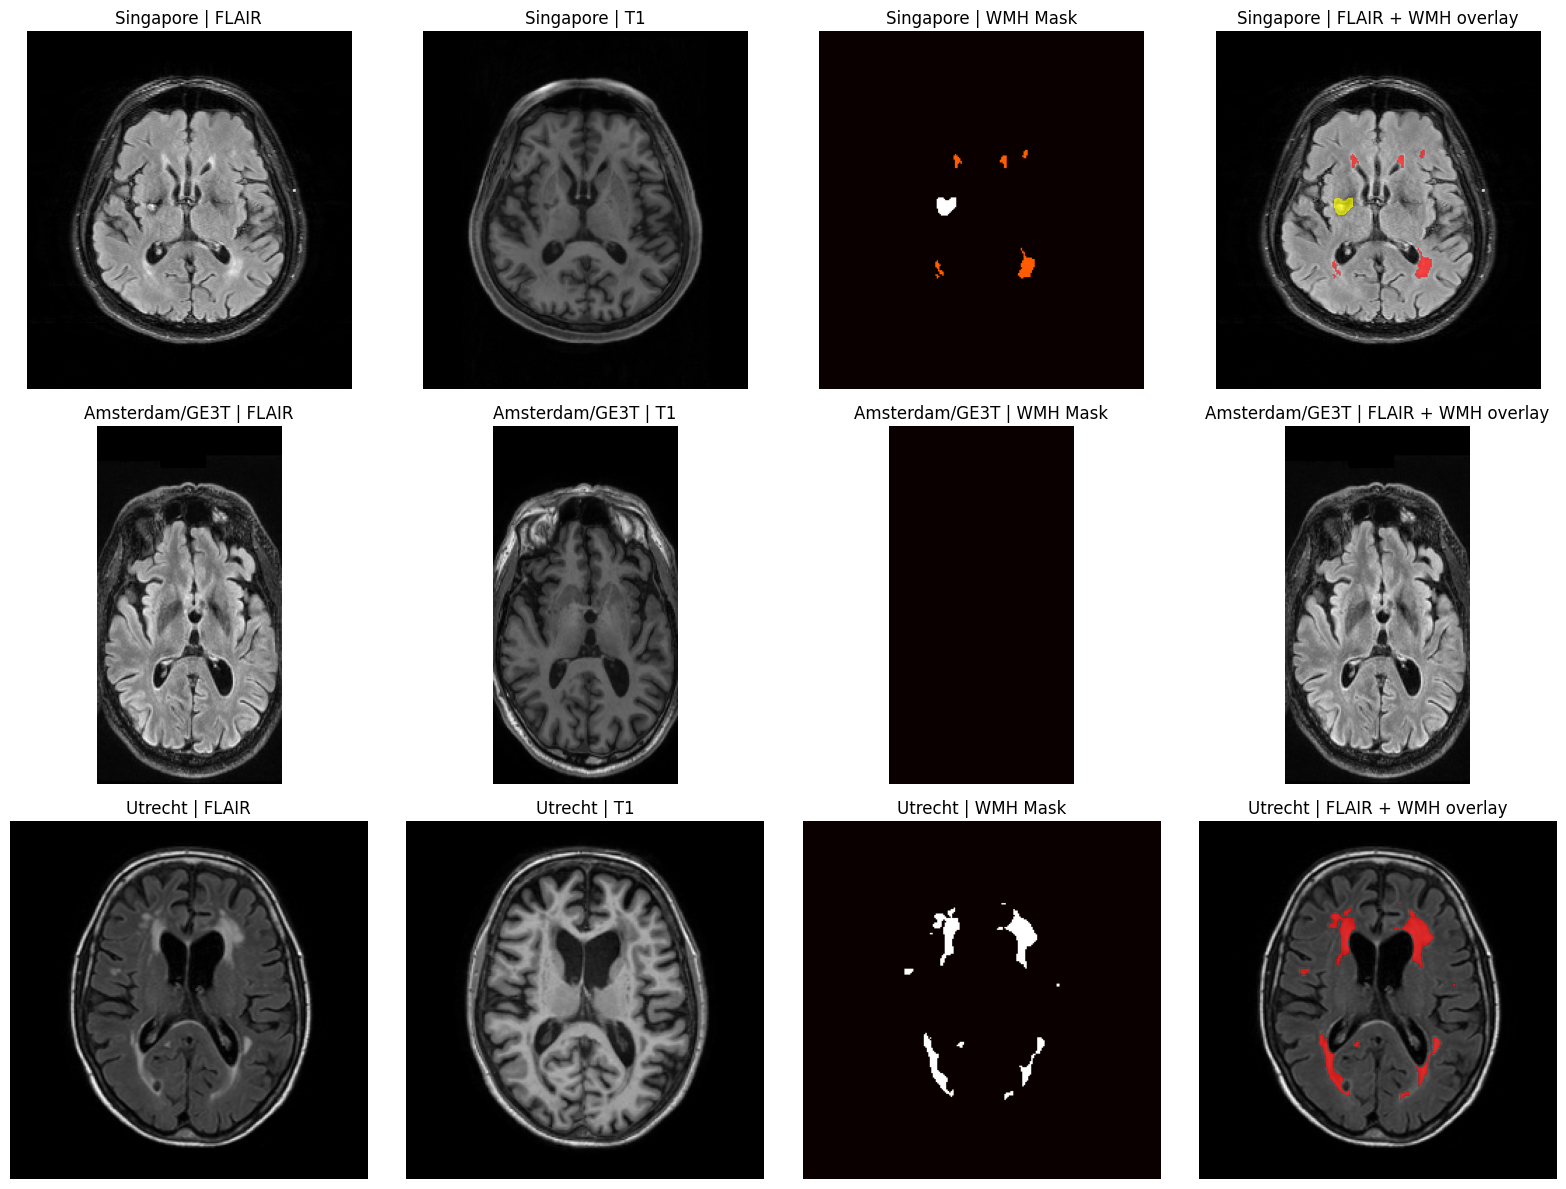

In [10]:
def get_middle_slice(arr):
    """Return the middle axial slice (first dim in SimpleITK array = z)"""
    return arr[arr.shape[0] // 2, :, :]

def normalize(arr):
    """Normalize to 0-1 for display"""
    arr = arr.astype(float)
    if arr.max() == arr.min():
        return arr
    return (arr - arr.min()) / (arr.max() - arr.min())

# Pick one representative case per site
site_examples = {}
random.shuffle(cases)
for case in cases:
    if case['site'] not in site_examples:
        site_examples[case['site']] = case

fig, axes = plt.subplots(len(site_examples), 4, figsize=(16, 4 * len(site_examples)))
col_titles = ['FLAIR', 'T1', 'WMH Mask', 'FLAIR + WMH overlay']

for row_idx, (site, case) in enumerate(site_examples.items()):
    flair_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(case['flair'])))
    t1_arr    = sitk.GetArrayFromImage(sitk.ReadImage(str(case['t1'])))
    wmh_arr   = sitk.GetArrayFromImage(sitk.ReadImage(str(case['wmh'])))

    flair_slice = get_middle_slice(flair_arr)
    t1_slice    = get_middle_slice(t1_arr)
    wmh_slice   = get_middle_slice(wmh_arr)

    ax = axes[row_idx] if len(site_examples) > 1 else axes

    ax[0].imshow(normalize(flair_slice), cmap='gray')
    ax[0].set_title(f'{site} | FLAIR')

    ax[1].imshow(normalize(t1_slice), cmap='gray')
    ax[1].set_title(f'{site} | T1')

    ax[2].imshow(wmh_slice, cmap='hot')
    ax[2].set_title(f'{site} | WMH Mask')

    # Overlay: FLAIR as gray + WMH as red
    ax[3].imshow(normalize(flair_slice), cmap='gray')
    masked = np.ma.masked_where(wmh_slice == 0, wmh_slice)
    ax[3].imshow(masked, cmap='autumn', alpha=0.7)
    ax[3].set_title(f'{site} | FLAIR + WMH overlay')

    for a in ax:
        a.axis('off')

plt.tight_layout()
#plt.savefig('exploration_slices.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Saved to exploration_slices.png')

## 5. Check intensity distributions across sites
Reason for this is if FLAIR intensity ranges differ widely across sites, we'll need normalization in the pipeline.

Singapore FLAIR (20 patients) — min: 0.4, max: 1927.6, mean: 68.5, std: 103.9
Amsterdam/GE3T FLAIR (20 patients) — min: 0.7, max: 2983.4, mean: 198.7, std: 246.8
Utrecht FLAIR (20 patients) — min: 1.4, max: 3179.9, mean: 308.6, std: 346.9


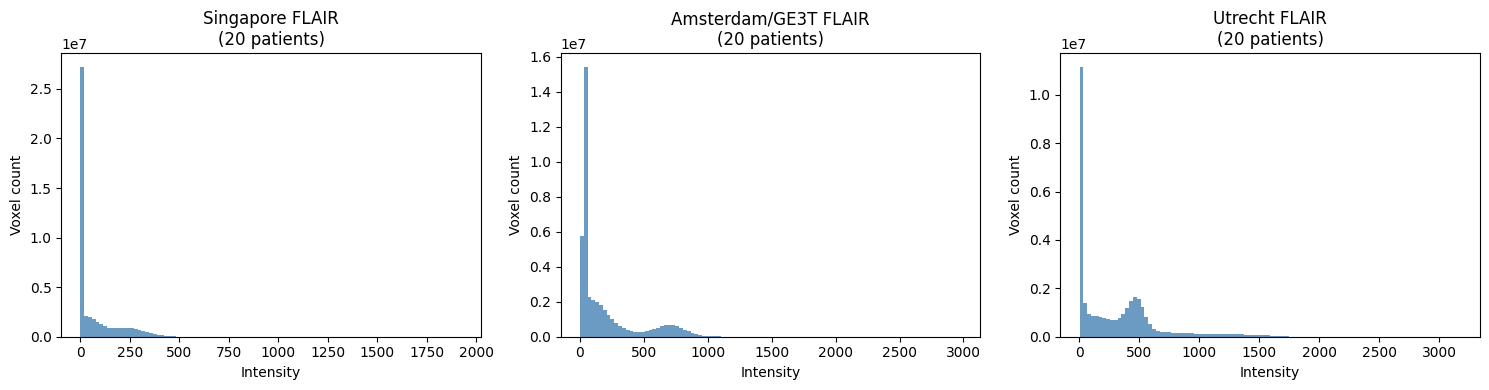

In [11]:
SITES = site_examples.keys()
fig, axes = plt.subplots(1, len(SITES), figsize=(15, 4))

for idx, site in enumerate(SITES):
    site_cases = [c for c in cases if c['site'] == site]
    
    all_intensities = []
    for case in site_cases:
        flair_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(case['flair']))).flatten()
        flair_brain = flair_arr[flair_arr > 0]
        all_intensities.append(flair_brain)
    
    # Plot each patient as a light line, plus a bold mean histogram
    all_concat = np.concatenate(all_intensities)
    axes[idx].hist(all_concat, bins=100, color='steelblue', alpha=0.8)
    axes[idx].set_title(f'{site} FLAIR\n({len(site_cases)} patients)')
    axes[idx].set_xlabel('Intensity')
    axes[idx].set_ylabel('Voxel count')
    
    print(f'{site} FLAIR ({len(site_cases)} patients) — '
          f'min: {all_concat.min():.1f}, max: {all_concat.max():.1f}, '
          f'mean: {all_concat.mean():.1f}, std: {all_concat.std():.1f}')

plt.tight_layout()
# plt.savefig('exploration_intensity_dists.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Explore the Test Set Structure
- This data will only be used for final evaluation but it's useful to confirm that it generally matches the train structure


In [12]:
TEST_ROOT = Path('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/test')
test_cases = discover_cases(TEST_ROOT)
print_case_summary(test_cases, label='TEST SET')

=== TEST SET ===
Amsterdam/GE1T5: 10 patients -> ['150', '151', '152', '153', '154', '155', '156', '157', '158', '159']
Amsterdam/GE3T: 30 patients -> ['111', '117', '118', '119', '120', '121', '122', '123', '124', '125', '127', '128', '129', '130', '131', '133', '134', '135', '136', '138', '139', '140', '141', '142', '143', '145', '146', '147', '148', '149']
Amsterdam/Philips_VU .PETMR_01.: 10 patients -> ['160', '161', '162', '163', '164', '165', '166', '167', '168', '169']
Singapore: 30 patients -> ['70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']
Utrecht: 30 patients -> ['1', '10', '12', '13', '14', '15', '16', '18', '20', '22', '24', '26', '28', '3', '30', '32', '34', '36', '38', '40', '42', '43', '44', '45', '46', '47', '48', '5', '7', '9']
Total usable cases: 110



In [13]:
# Check shapes, spacings, and mask values for test set
test_shapes = defaultdict(set)
test_spacings = defaultdict(set)
test_wmh_stats = []

for case in test_cases:
    if case['missing']:
        continue
    flair_info = get_image_info(case['flair'])
    wmh_img = sitk.ReadImage(str(case['wmh']))
    wmh_arr = sitk.GetArrayFromImage(wmh_img)
    unique_vals = np.unique(wmh_arr)

    lesion_voxels = np.sum(wmh_arr == 1)
    voxel_vol = np.prod(wmh_img.GetSpacing())
    lesion_vol_ml = round((lesion_voxels * voxel_vol) / 1000, 3)

    test_shapes[case['site']].add(flair_info['size'])
    test_spacings[case['site']].add(flair_info['spacing'])
    test_wmh_stats.append({
        'site': case['site'], 'pid': case['patient_id'],
        'unique_vals': unique_vals, 'lesion_vol_ml': lesion_vol_ml
    })

print('\n--- Unique FLAIR shapes per site (test) ---')
for site, sh in test_shapes.items():
    print(f'  {site}: {sh}')

print('\n--- Unique FLAIR spacings per site (test) ---')
for site, sp in test_spacings.items():
    print(f'  {site}: {sp}')


--- Unique FLAIR shapes per site (test) ---
  Amsterdam/GE1T5: {(124, 256, 103), (128, 256, 103)}
  Amsterdam/GE3T: {(136, 256, 83), (140, 256, 83), (124, 256, 83), (132, 256, 83)}
  Amsterdam/Philips_VU .PETMR_01.: {(321, 240, 83)}
  Singapore: {(232, 256, 48)}
  Utrecht: {(240, 240, 48)}

--- Unique FLAIR spacings per site (test) ---
  Amsterdam/GE1T5: {(1.3, 1.211, 3.0)}
  Amsterdam/GE3T: {(1.2, 0.977, 3.0)}
  Amsterdam/Philips_VU .PETMR_01.: {(0.56, 1.042, 3.0)}
  Singapore: {(1.0, 1.0, 3.0)}
  Utrecht: {(0.958, 0.958, 3.0)}


In [14]:
# Compare training vs test site overlap
train_sites = set(c['site'] for c in cases)
test_sites  = set(c['site'] for c in test_cases)

print('Training sites:', sorted(train_sites))
print('Test sites:    ', sorted(test_sites))

new_test_sites = test_sites - train_sites
if new_test_sites:
    print(f'\nWARNING: These test sites are NOT in training (out-of-distribution):')
    for s in sorted(new_test_sites):
        count = sum(1 for c in test_cases if c['site'] == s)
        print(f'  {s}: {count} cases')
    print('These cases will test generalization to unseen scanners.')
else:
    print('\nAll test sites appear in training -- good!')

Training sites: ['Amsterdam/GE3T', 'Singapore', 'Utrecht']
Test sites:     ['Amsterdam/GE1T5', 'Amsterdam/GE3T', 'Amsterdam/Philips_VU .PETMR_01.', 'Singapore', 'Utrecht']

  Amsterdam/GE1T5: 10 cases
  Amsterdam/Philips_VU .PETMR_01.: 10 cases
These cases will test generalization to unseen scanners.


## 6. Summary — things to note before building the pipeline

In [15]:
print('=== SUMMARY ===')
print(f'Total Train cases: {len(cases)}')
for site in SITES:
    site_cases = [c for c in cases if c['site'] == site]
    print(f'  {site}: {len(site_cases)} cases')

print(f'\nTotal Test cases: {len(test_cases)}')
for site in test_sites:
    site_cases = [c for c in test_cases if c['site'] == site]
    print(f'  {site}: {len(site_cases)} cases')


print(f'\nUnique shapes across train dataset:')
for site, sh in shapes.items():
    print(f'  {site}: {sh}')

print(f'\nUnique spacings across train dataset:')
for site, sp in spacings.items():
    print(f'  {site}: {sp}')

print('\nThings to handle in the pipeline:')
print('  1. Resample all images to a common spacing (since spacings differ across sites)')
print('  2. Normalize FLAIR intensities (Using z-score per patient)')
print('  3. Convert to mask binarization strategy (Value of 2 is converted to background)')
print('  4. Use pre/ folder (not orig/) for all inputs')

=== SUMMARY ===
Total Train cases: 60
  Singapore: 20 cases
  Amsterdam/GE3T: 20 cases
  Utrecht: 20 cases

Total Test cases: 110
  Amsterdam/Philips_VU .PETMR_01.: 10 cases
  Amsterdam/GE1T5: 10 cases
  Utrecht: 30 cases
  Amsterdam/GE3T: 30 cases
  Singapore: 30 cases

Unique shapes across train dataset:
  Amsterdam/GE3T: {(132, 256, 83)}
  Singapore: {(256, 232, 48), (232, 256, 48)}
  Utrecht: {(240, 240, 48)}

Unique spacings across train dataset:
  Amsterdam/GE3T: {(1.2, 0.977, 3.0)}
  Singapore: {(1.0, 1.0, 3.0)}
  Utrecht: {(0.958, 0.958, 3.0)}

Things to handle in the pipeline:
  1. Resample all images to a common spacing (since spacings differ across sites)
  2. Normalize FLAIR intensities (Using z-score per patient)
  3. Convert to mask binarization strategy (Value of 2 is converted to background)
  4. Use pre/ folder (not orig/) for all inputs
